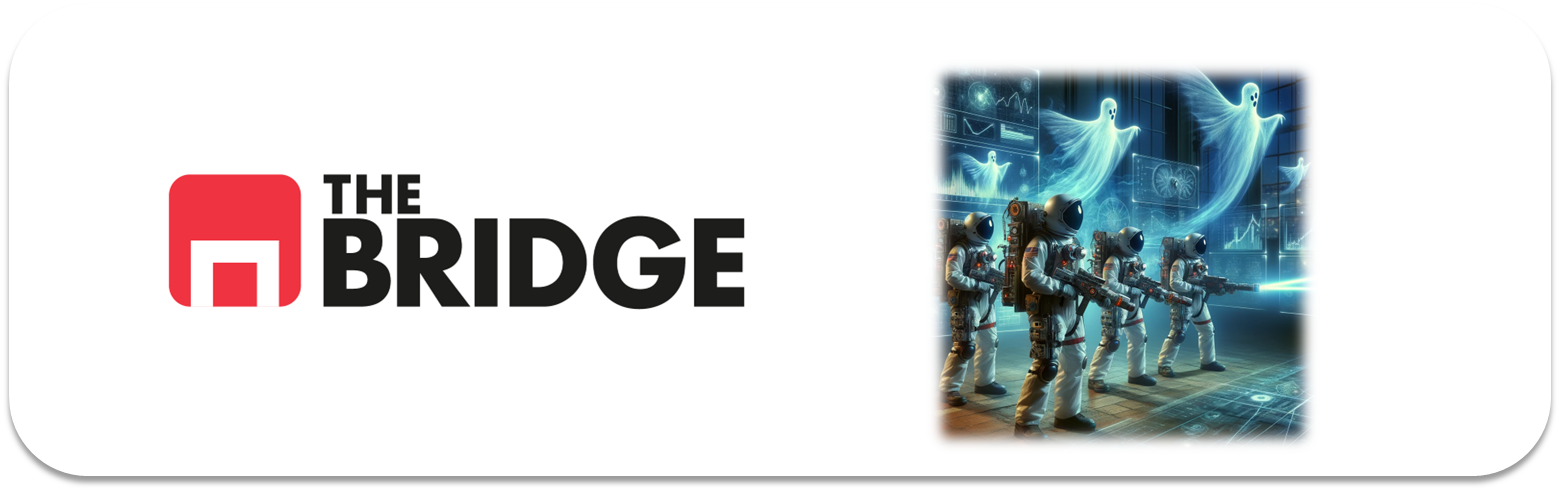

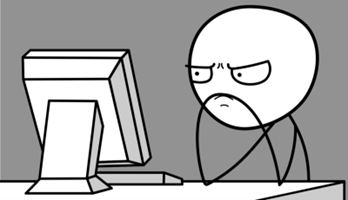

Para ejercitarte y afianzar lo aprendido sobre **Series Temporales**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### El "problema"

Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolinea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

### Ejercicio 1

Carga los datos y adecúa el dataset teniendo en cuenta que es una serie temporal. Para ello convierte la columna de fecha al formato adecuado y luego úsala como índice.

### Ejercicio 2

¿De qué fecha a qué fecha va el histórico?¿Qué periodicidad tiene la serie?

### Ejercicio 3

¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad? Analiza de manera gráfica, pero todavía sin descomponer la serie.

### Ejercicio 4

¿Podrías demostrar de dos maneras estadísticas que la serie no es estacionaria?

### Ejercicio 5

Emplea la descomposición que hemos aprendido en el workout para representar gráficamente la tendencia. Si has mostrado gráficamente la tendencia en el ejercicio 3, compara ambos.

### Ejercicio 6

Visualiza todos los componentes de la serie temporal por separado

### Ejercicio 7

Crea una matriz de correlación con los últimos 24 instantes (matriz de autocorrelación). Crea un dataframe con shift de 1 a 24 para ello, la idea es que puedas hacer una matriz de correlación con el valor actual y los 24 valores anteriores. Es decir de un mes con sus 23 meses anteriores. Interpreta la estacionalidad

### Ejercicio 8
Ya hemos visto que hay seasonality. ¿Cada cuántos instantes se cumple ese patrón?

### Ejercicio 9

 Divide en train y test. En este caso no haremos división en validación, entre otras razones por la cantidad de datos que tenemos. Guarda 20 muestras para test.

### Ejercicio 10

Pon en práctica lo visto en clases, crea un modelo de ARIMA (puedes utilizar autoarima), mide su RMSE y su MAPE. Comparalo gráficamente con los valores reales.

### Ejercicio 11

Haz lo mismo que en el ejercicio 10 pero con un modelo SARIMA. ¿Cuál es mejor y por qué?

Rango de fechas: 1949-01-01 00:00:00 a 1960-12-01 00:00:00
Periodicidad inferida: MS


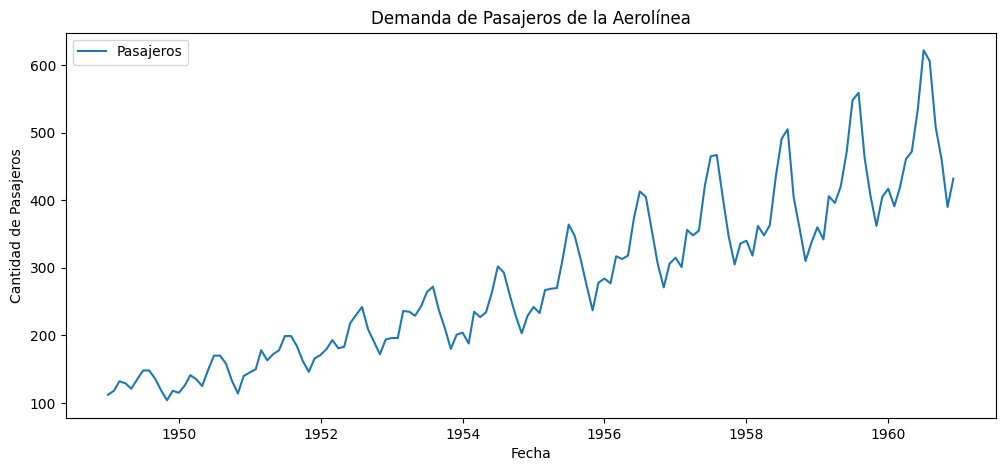

p-valor Dickey-Fuller: 0.991880243437641
Cambio en la varianza: 1666.5344972756498


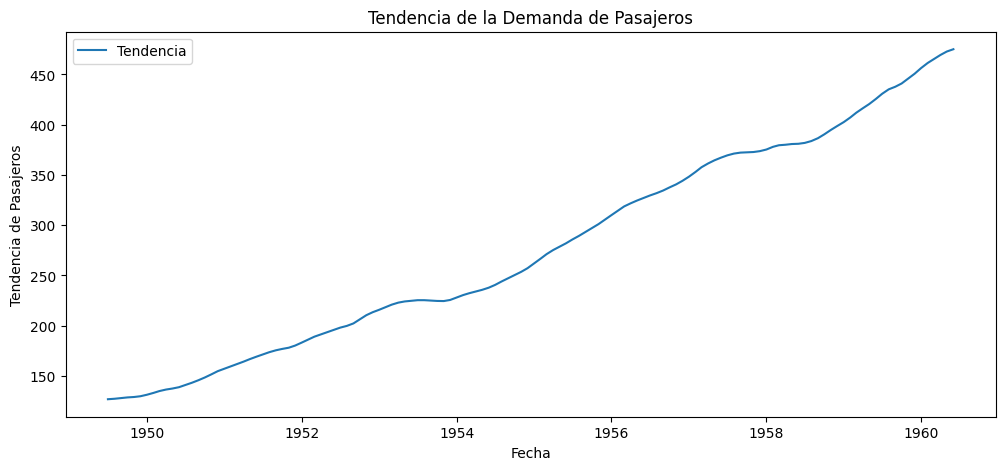

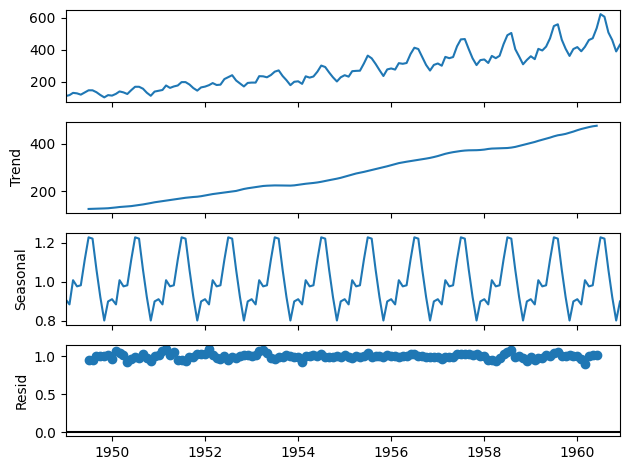

Matriz de autocorrelación:
            Lag_1     Lag_2     Lag_3     Lag_4     Lag_5     Lag_6     Lag_7  \
Lag_1   1.000000  0.960249  0.894473  0.836002  0.799965  0.789839  0.783123   
Lag_2   0.960249  1.000000  0.961133  0.896597  0.844427  0.810070  0.793150   
Lag_3   0.894473  0.961133  1.000000  0.960920  0.899075  0.846777  0.807324   
Lag_4   0.836002  0.896597  0.960920  1.000000  0.962171  0.898945  0.842121   
Lag_5   0.799965  0.844427  0.899075  0.962171  1.000000  0.959887  0.894424   
Lag_6   0.789839  0.810070  0.846777  0.898945  0.959887  1.000000  0.959373   
Lag_7   0.783123  0.793150  0.807324  0.842121  0.894424  0.959373  1.000000   
Lag_8   0.782117  0.783274  0.789193  0.802115  0.838784  0.894852  0.959009   
Lag_9   0.789786  0.782019  0.779140  0.783723  0.797732  0.837280  0.892632   
Lag_10  0.825743  0.788745  0.778509  0.775250  0.782939  0.799273  0.835987   
Lag_11  0.881441  0.824712  0.786193  0.776281  0.777582  0.787776  0.799379   
Lag_12  0.94

c:\Users\DMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\DMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\DMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ARIMA - RMSE: 113.90737761685155 | MAPE: 0.17586766342320073


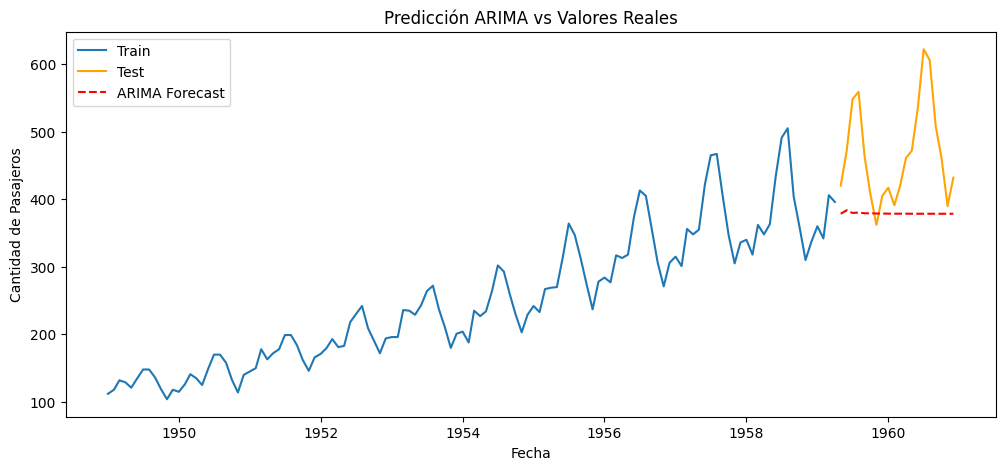

c:\Users\DMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\DMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\DMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA - RMSE: 31.257759478041116 | MAPE: 0.05834928919878474


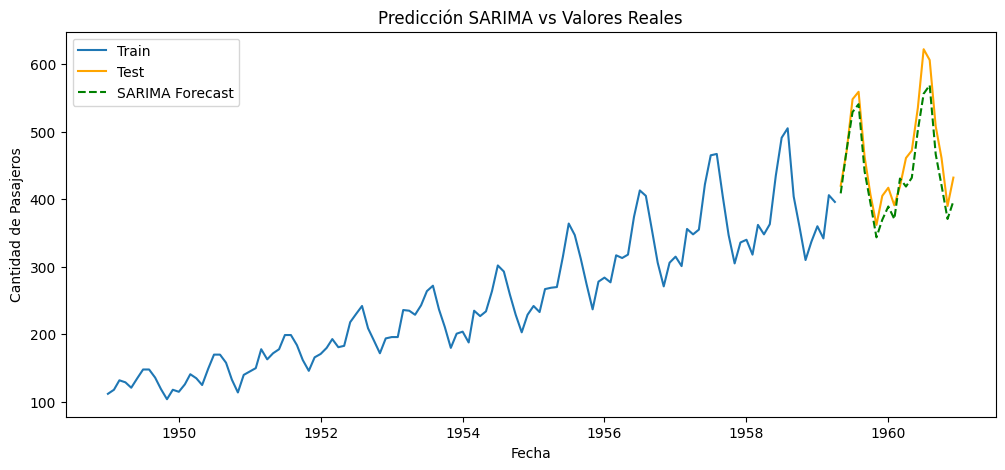

Comparación de modelos:
ARIMA  - RMSE: 113.90737761685155 | MAPE: 0.17586766342320073
SARIMA - RMSE: 31.257759478041116 | MAPE: 0.05834928919878474


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# Cargar los datos
file_path = "./data/AirPassengers.csv"
df = pd.read_csv(file_path)

# Convertir fecha a datetime y establecer como índice
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Mostrar rango de fechas y periodicidad
print("Rango de fechas:", df.index.min(), "a", df.index.max())
print("Periodicidad inferida:", pd.infer_freq(df.index))

# Graficar la serie temporal
plt.figure(figsize=(12,5))
plt.plot(df, label="Pasajeros")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de Pasajeros")
plt.title("Demanda de Pasajeros de la Aerolínea")
plt.legend()
plt.show()

# Prueba de Dickey-Fuller
adf_test = adfuller(df['value'])
print("p-valor Dickey-Fuller:", adf_test[1])

# Calcular varianza en diferentes ventanas de tiempo
rolling_var = [np.var(df['value'].iloc[i:i+12]) for i in range(len(df)-12)]
print("Cambio en la varianza:", np.std(rolling_var))

# Descomposición de la serie
decomposition = seasonal_decompose(df, model='multiplicative', period=12)

# Graficar la tendencia
plt.figure(figsize=(12,5))
plt.plot(decomposition.trend, label="Tendencia")
plt.xlabel("Fecha")
plt.ylabel("Tendencia de Pasajeros")
plt.title("Tendencia de la Demanda de Pasajeros")
plt.legend()
plt.show()

# Visualizar todos los componentes de la serie temporal
decomposition.plot()
plt.show()

# Crear matriz de autocorrelación con los últimos 24 meses
df_lags = pd.concat([df.shift(i) for i in range(1, 25)], axis=1)
df_lags.columns = [f"Lag_{i}" for i in range(1, 25)]
correlation_matrix = df_lags.corr()
print("Matriz de autocorrelación:\n", correlation_matrix)

# División en train y test (20 muestras para test)
train_size = len(df) - 20
train, test = df.iloc[:train_size], df.iloc[train_size:]
print("Tamaño Train:", train.shape, "| Tamaño Test:", test.shape)

# Ajustar modelo ARIMA manualmente
arima_model = ARIMA(train, order=(2,1,2)).fit()
arima_forecast = arima_model.forecast(steps=len(test))

# Calcular métricas de error ARIMA
rmse_arima = np.sqrt(mean_squared_error(test, arima_forecast))
mape_arima = mean_absolute_percentage_error(test, arima_forecast)
print("ARIMA - RMSE:", rmse_arima, "| MAPE:", mape_arima)

# Graficar predicciones de ARIMA vs valores reales
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test", color='orange')
plt.plot(test.index, arima_forecast, label="ARIMA Forecast", linestyle="dashed", color='red')
plt.xlabel("Fecha")
plt.ylabel("Cantidad de Pasajeros")
plt.title("Predicción ARIMA vs Valores Reales")
plt.legend()
plt.show()

# Ajustar modelo SARIMA manualmente
sarima_model = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,12)).fit()
sarima_forecast = sarima_model.forecast(steps=len(test))

# Calcular métricas de error SARIMA
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_forecast))
mape_sarima = mean_absolute_percentage_error(test, sarima_forecast)
print("SARIMA - RMSE:", rmse_sarima, "| MAPE:", mape_sarima)

# Graficar predicciones de SARIMA vs valores reales
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test", color='orange')
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast", linestyle="dashed", color='green')
plt.xlabel("Fecha")
plt.ylabel("Cantidad de Pasajeros")
plt.title("Predicción SARIMA vs Valores Reales")
plt.legend()
plt.show()

# Comparación final
print("Comparación de modelos:")
print("ARIMA  - RMSE:", rmse_arima, "| MAPE:", mape_arima)
print("SARIMA - RMSE:", rmse_sarima, "| MAPE:", mape_sarima)